In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, KMeansSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter

In [12]:
base_path = ""

In [6]:
n_majority = 1000
n_minority = 100
majority_mean = [1, -1, 1]
majority_std = [2, 1, 2]
minority_mean = [-1, 1, -1]
minority_std = [1, 2, 1]

In [7]:
majority_x = np.random.normal(loc=majority_mean, scale=majority_std, size=(n_majority, 3))
minority_x = np.random.normal(loc=minority_mean, scale=minority_std, size=(n_minority, 3))
majority_y = np.zeros(n_majority)
minority_y = np.ones(n_minority)

In [8]:
x = np.vstack((majority_x, minority_x))
y = np.hstack((majority_y, minority_y))

In [9]:
data = pd.DataFrame(data=x, columns=["F1", "F2", "F3"])
data["target"] = y

In [13]:
data.head()
data.to_csv(f"{base_path}data.csv", index=False)

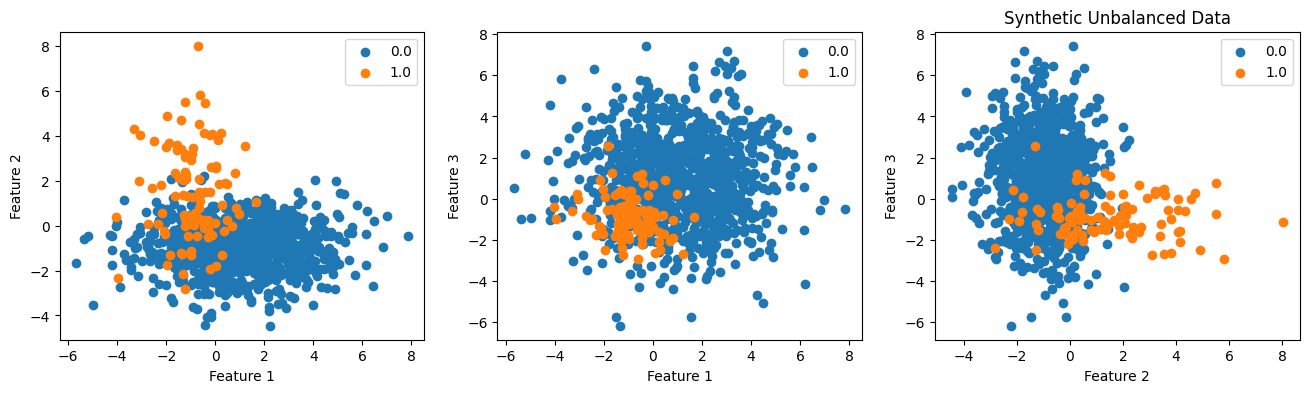

In [14]:
majority_data = data[data["target"] == 0.0]
minority_data = data[data["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("Synthetic Unbalanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}data.png")
plt.show()

## SMOTE

In [15]:
features = ["F1", "F2", "F3"]
target = "target"
smote = SMOTE()
df_smote, target_smote = smote.fit_resample(data[features], data[target])
df_smote['target'] = target_smote
df_smote.to_csv(f"{base_path}smote.csv", index=False)

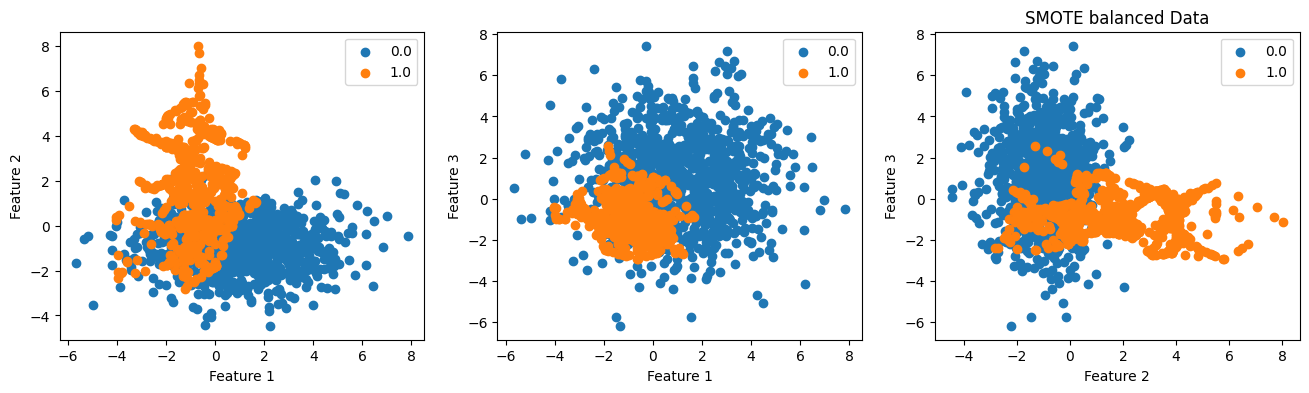

In [16]:
majority_data = df_smote[df_smote["target"] == 0.0]
minority_data = df_smote[df_smote["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("SMOTE balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}smote.png")
plt.show()

## SMOTE TomekLinks

In [17]:
tomeklinks = SMOTETomek()
df_tomek, target_tomek = tomeklinks.fit_resample(data[features], data[target])
df_tomek[target] = target_tomek
df_tomek.to_csv(f"{base_path}tomek.csv", index=False)

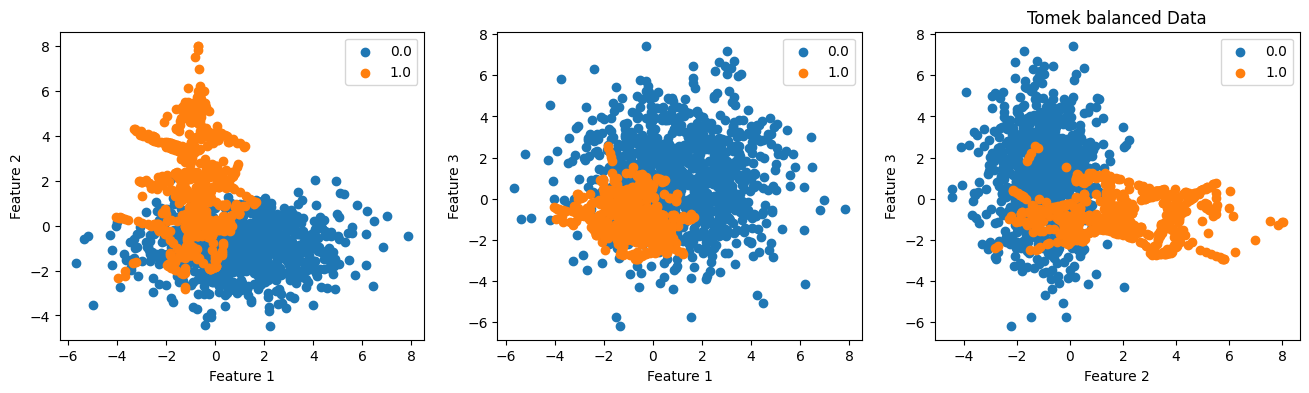

In [18]:
majority_data = df_tomek[df_tomek["target"] == 0.0]
minority_data = df_tomek[df_tomek["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("Tomek balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}tomek.png")
plt.show()

## SMOTE ENN

In [19]:
enn = SMOTEENN()
df_enn, target_enn = enn.fit_resample(data[features], data[target])
df_enn[target] = target_enn
df_enn.to_csv(f"{base_path}enn.csv", index=False)

In [31]:
df_enn["target"].value_counts()

target
1.0    898
0.0    864
Name: count, dtype: int64

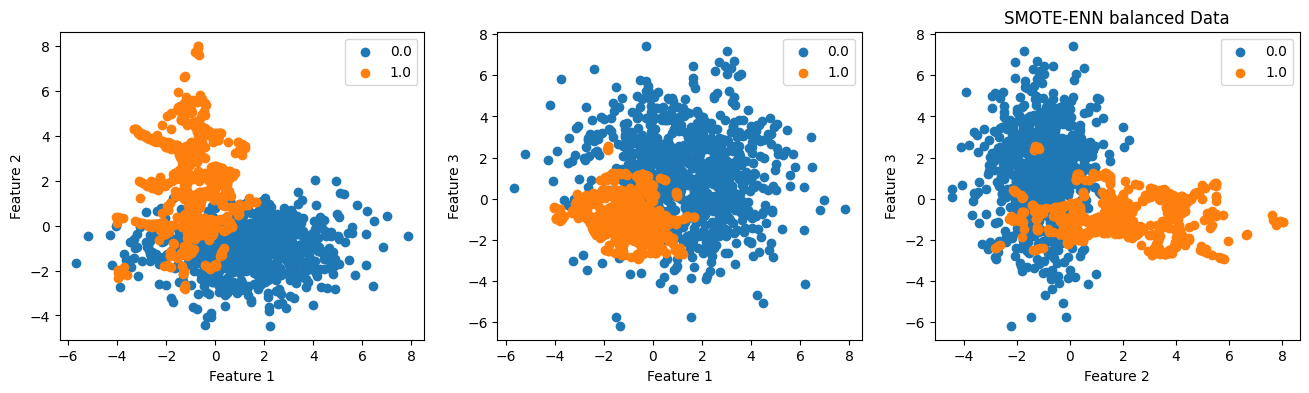

In [20]:
majority_data = df_enn[df_enn["target"] == 0.0]
minority_data = df_enn[df_enn["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("SMOTE-ENN balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}enn.png")
plt.show()

## Borderline SMOTE 1

In [21]:
bsmort1 = BorderlineSMOTE(kind='borderline-1')
df_b1, target_b1 = bsmort1.fit_resample(data[features], data[target])
df_b1[target] = target_b1
df_b1.to_csv(f"{base_path}b1.csv", index=False)

In [32]:
df_b1["target"].value_counts()

target
0.0    1000
1.0    1000
Name: count, dtype: int64

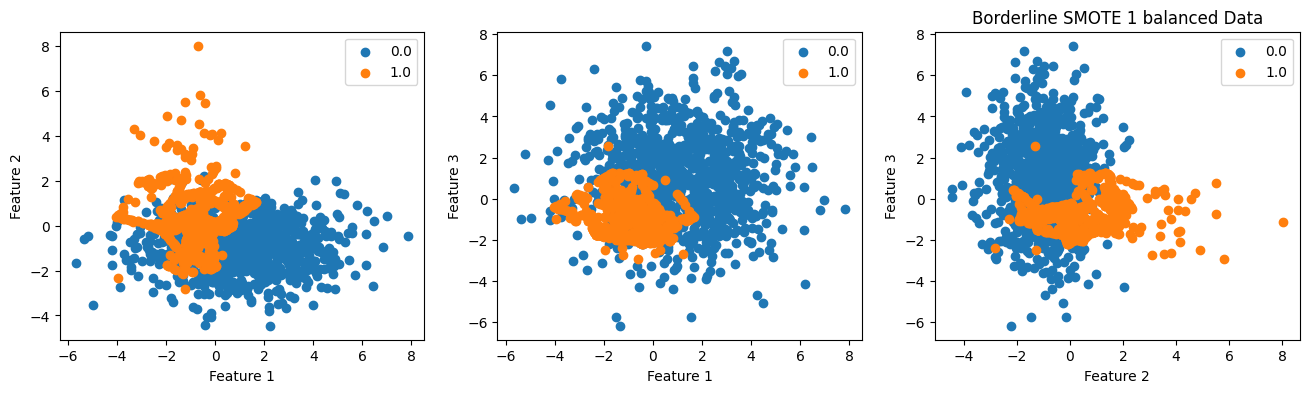

In [22]:
majority_data = df_b1[df_b1["target"] == 0.0]
minority_data = df_b1[df_b1["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("Borderline SMOTE 1 balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}b1.png")
plt.show()

## Borderline SMOTE 2

In [23]:
bsmort2 = BorderlineSMOTE(kind='borderline-2')
df_b2, target_b2 = bsmort2.fit_resample(data[features], data[target])
df_b2[target] = target_b2
df_b2.to_csv(f"{base_path}b2.csv", index=False)

In [33]:
df_b2["target"].value_counts()

target
0.0    1000
1.0    1000
Name: count, dtype: int64

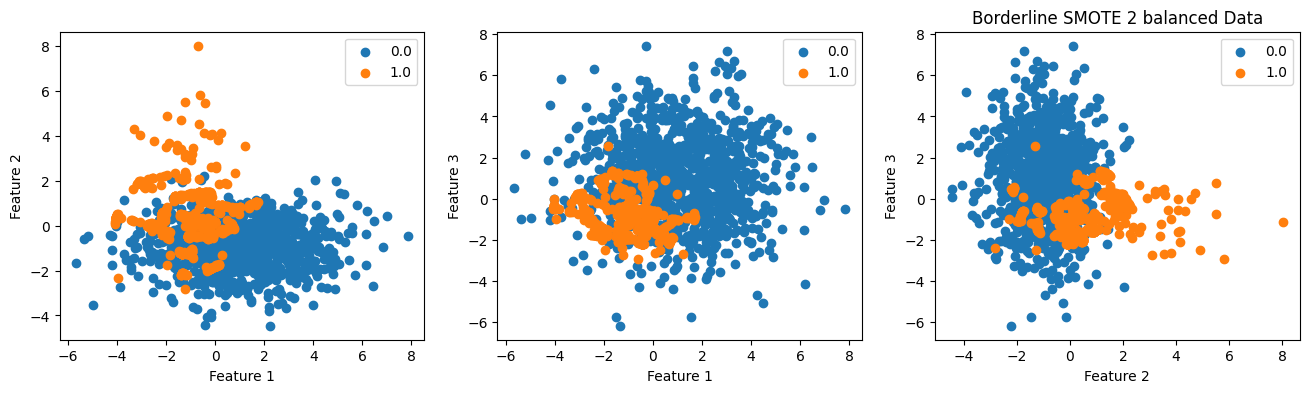

In [24]:
majority_data = df_b2[df_b2["target"] == 0.0]
minority_data = df_b2[df_b2["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("Borderline SMOTE 2 balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}b2.png")
plt.show()

## Kmeans SMOTE

In [25]:
kmean = KMeansSMOTE()
df_kmean, target_kmean = kmean.fit_resample(data[features], data[target])
df_kmean[target] = target_kmean
df_kmean.to_csv(f"{base_path}kmean.csv", index=False)

In [34]:
df_kmean["target"].value_counts()

target
0.0    1000
1.0    1000
Name: count, dtype: int64

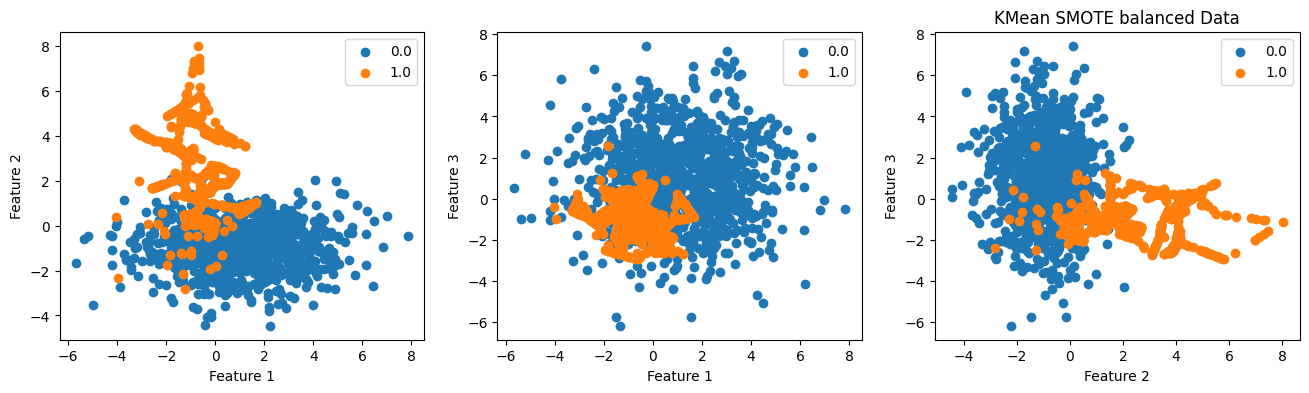

In [26]:
majority_data = df_kmean[df_kmean["target"] == 0.0]
minority_data = df_kmean[df_kmean["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("KMean SMOTE balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}kmean.png")
plt.show()

## ADASYN

In [27]:
adasyn = ADASYN()
df_adasyn, target_adasyn = adasyn.fit_resample(data[features], data[target])
df_adasyn[target] = target_adasyn
df_adasyn.to_csv(f"{base_path}adasyn.csv", index=False)

In [ ]:
df_adasyn["target"]

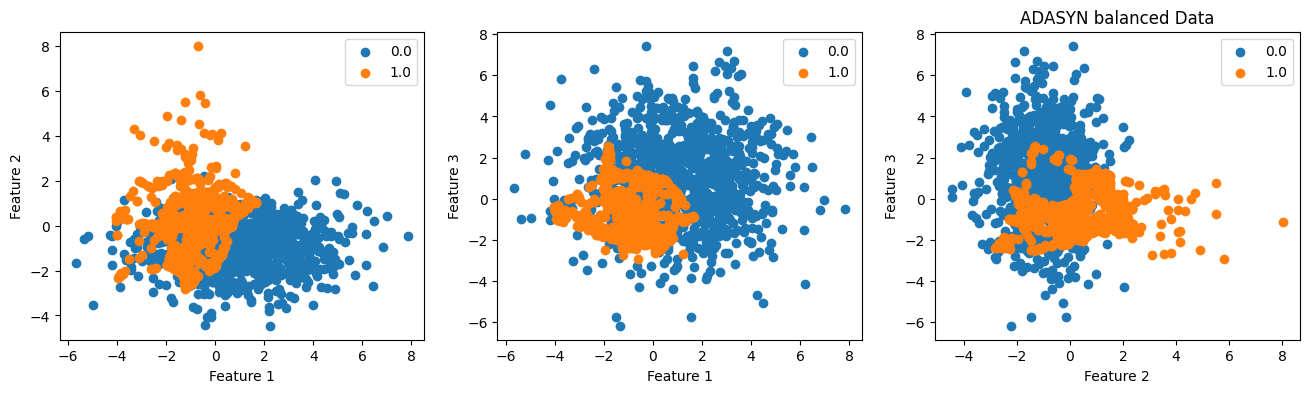

In [28]:
majority_data = df_adasyn[df_adasyn["target"] == 0.0]
minority_data = df_adasyn[df_adasyn["target"] == 1.0]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
plt.title("ADASYN balanced Data")

axs[0].scatter(majority_data["F1"], majority_data["F2"], label="0.0")
axs[0].scatter(minority_data["F1"], minority_data["F2"], label="1.0")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].legend()

axs[1].scatter(majority_data["F1"], majority_data["F3"], label="0.0")
axs[1].scatter(minority_data["F1"], minority_data["F3"], label="1.0")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 3")
axs[1].legend()

axs[2].scatter(majority_data["F2"], majority_data["F3"], label="0.0")
axs[2].scatter(minority_data["F2"], minority_data["F3"], label="1.0")
axs[2].set_xlabel("Feature 2")
axs[2].set_ylabel("Feature 3")
axs[2].legend()
plt.savefig(f"{base_path}adasyn.png")
plt.show()